# Data Cleaning & Exploratory Data Analysis
**Project**: Statistical Machine Learning - Project 1
**Dataset**: Home Credit Default Risk
**Author**: [Your Name] (Data Cleaning / EDA / Report Integration)

---
## Scope
This notebook covers **general-purpose data cleaning and descriptive EDA only**.
Feature engineering (one-hot encoding, scaling, feature selection) is intentionally
left to each modeling member (Logistic Regression, Random Forest, XGBoost) because
different models require different preprocessing.

## Pipeline
1. Load raw data
2. Basic structural inspection
3. Missing value analysis
4. Duplicate row check
5. Outlier detection (record only, do not delete)
6. Dtype standardization
7. Save cleaned dataset
8. Descriptive EDA (target distribution, numeric summaries, categorical summaries, correlation)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Paths (adjust if your directory layout differs)
DATA_DIR  = '../data/'
FIG_DIR   = '../figures/'

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Raw Data
The Home Credit dataset consists of multiple CSV tables. We start with the main
application table (`application_train.csv`), which contains one row per loan
application and the target variable `TARGET` (1 = client had payment difficulties,
0 = all other cases).

**Before running this cell**, download the raw data from Kaggle:
https://www.kaggle.com/competitions/home-credit-default-risk/data
and place the CSVs into `data/raw/` (or change `DATA_DIR` above).

In [3]:
# Load main application table
train = pd.read_csv(DATA_DIR + 'application_train.csv')

print(f'Shape: {train.shape}')
print(f'Columns: {train.shape[1]}')
train.head()

Shape: (307511, 122)
Columns: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


---
## 2. Basic Structural Inspection

In [5]:
# Separate numeric vs categorical columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols     = train.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns: {len(numeric_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print()
print('Categorical columns:', cat_cols)

Numeric columns: 106
Categorical columns: 16

Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [6]:
# Check ID column uniqueness
print(f'SK_ID_CURR unique: {train["SK_ID_CURR"].nunique()} == {len(train)} rows? {train["SK_ID_CURR"].nunique() == len(train)}')

SK_ID_CURR unique: 307511 == 307511 rows? True


---
## 3. Missing Value Analysis
We compute missing counts and ratios for every column. Columns with > 40% missing
are flagged as **high-missing**; we do not drop them here because tree-based models
can handle missing values natively, and Logistic Regression members may choose
imputation strategies themselves.

In [7]:
missing_stats = pd.DataFrame({
    'missing_count': train.isnull().sum(),
    'missing_ratio': train.isnull().mean()
}).sort_values('missing_ratio', ascending=False)

# Only show columns that have at least 1 missing
missing_stats = missing_stats[missing_stats['missing_count'] > 0]
print(f'Columns with missing values: {len(missing_stats)} / {train.shape[1]}')
missing_stats.head(20)

Columns with missing values: 67 / 122


,missing_count,missing_ratio
COMMONAREA_MEDI,214865,0.698723
COMMONAREA_AVG,214865,0.698723
COMMONAREA_MODE,214865,0.698723
NONLIVINGAPARTMENTS_MODE,213514,0.694330
NONLIVINGAPARTMENTS_AVG,213514,0.694330
NONLIVINGAPARTMENTS_MEDI,213514,0.694330
FONDKAPREMONT_MODE,210295,0.683862
LIVINGAPARTMENTS_MODE,210199,0.683550
LIVINGAPARTMENTS_AVG,210199,0.683550
LIVINGAPARTMENTS_MEDI,210199,0.683550


In [8]:
# Flag high-missing columns (> 40%)
high_missing_cols = missing_stats[missing_stats['missing_ratio'] > 0.4].index.tolist()
print(f'High-missing columns (>40%): {len(high_missing_cols)}')
print(high_missing_cols)

High-missing columns (>40%): 49
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'LANDAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'EXT_SOURCE_1', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'ELEVATORS_MEDI', 'ELEVATORS_AVG', 'ELEVATORS_MODE', 'WALLSMATERIAL_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'APARTMENTS_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'ENTRANCES_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MODE', 'LIVINGAREA_MEDI', 'HOUSETYPE_MODE', 'FLOORSMAX_MODE', 'FLOORSMAX_MEDI', 'FLOORSMAX_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'TOTAL

In [9]:
# Save missing stats to CSV for reporting
missing_stats.to_csv(DATA_DIR + 'missing_statistics.csv')
print('Saved missing_statistics.csv')

Saved missing_statistics.csv


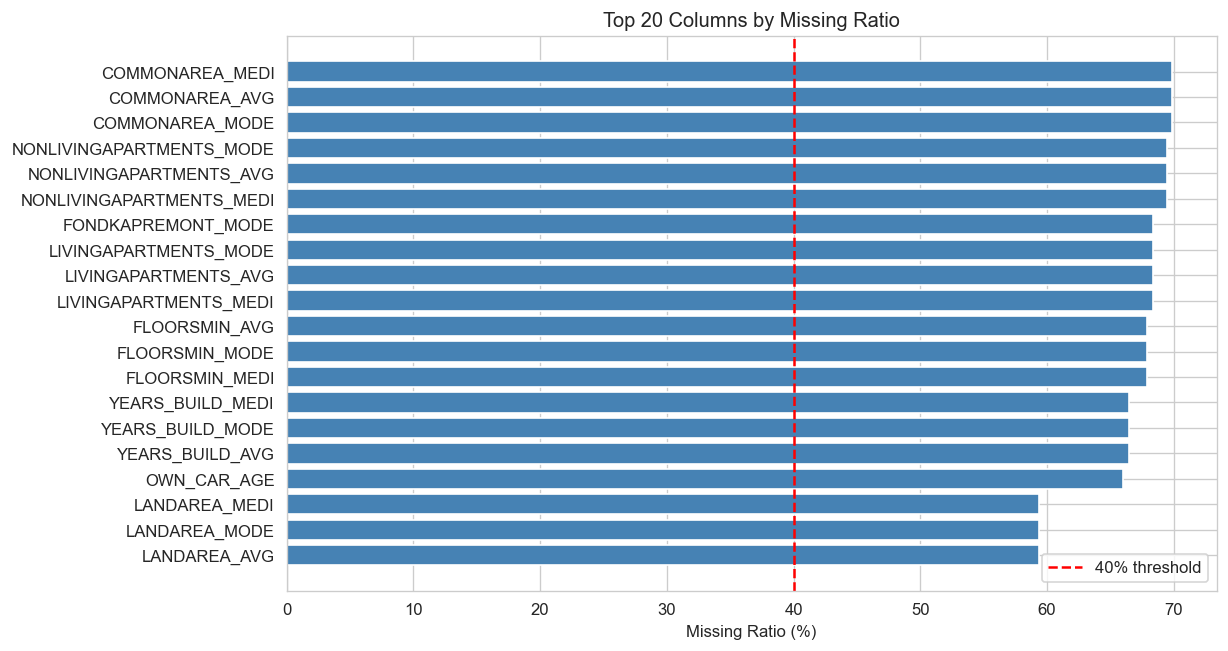

In [10]:
# Visualize top 20 missing ratios
fig, ax = plt.subplots(figsize=(10, 6))
top_missing = missing_stats.head(20).iloc[::-1]  # reverse for horizontal bar
ax.barh(top_missing.index, top_missing['missing_ratio'] * 100, color='steelblue')
ax.set_xlabel('Missing Ratio (%)')
ax.set_title('Top 20 Columns by Missing Ratio')
ax.axvline(40, color='red', linestyle='--', label='40% threshold')
ax.legend()
plt.savefig(FIG_DIR + 'missing_ratio_top20.png')
plt.show()

### Basic Imputation (minimal, intentionally conservative)
We apply **only trivial imputations** that do not distort model behavior:
- Categorical: fill missing with `'Unknown'`
- Numeric: leave as NaN for tree models; Logistic Regression members can apply
  their own median/mean imputation.

We **do not** do KNN imputation, MICE, or advanced imputation here.

In [11]:
# Minimal categorical imputation: 'Unknown'
for col in cat_cols:
    train[col] = train[col].fillna('Unknown')

print('Categorical NaN filled with "Unknown".')
print('Numeric NaN left as-is for model-specific imputation.')

Categorical NaN filled with "Unknown".
Numeric NaN left as-is for model-specific imputation.


---
## 4. Duplicate Row Check

In [12]:
dup_count = train.duplicated().sum()
print(f'Duplicate rows: {dup_count}')
if dup_count > 0:
    train = train.drop_duplicates()
    print(f'After dropping duplicates: {train.shape}')
else:
    print('No duplicates found.')

Duplicate rows: 0
No duplicates found.


---
## 5. Outlier Detection (record only)
We inspect extreme values in key numeric features using IQR and boxplots.
**We do not delete outliers** — they are likely genuine high-risk clients and
removing them would bias the model. We only document them for the report.

In [13]:
# Key numeric features to inspect
key_numeric = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH',
                'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
key_numeric = [c for c in key_numeric if c in train.columns]

outlier_summary = []
for col in key_numeric:
    s = train[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((s < low) | (s > high)).sum()
    outlier_summary.append({'feature': col, 'n_outliers': n_out,
                           'outlier_ratio': n_out / len(s)})

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.to_csv(DATA_DIR + 'outlier_summary.csv', index=False)
outlier_df

,feature,n_outliers,outlier_ratio
0,AMT_INCOME_TOTAL,14035,0.045641
1,AMT_CREDIT,6562,0.021339
2,AMT_ANNUITY,7504,0.024403
3,DAYS_BIRTH,0,0.000000
4,DAYS_EMPLOYED,72217,0.234844
5,EXT_SOURCE_1,0,0.000000
6,EXT_SOURCE_2,0,0.000000
7,EXT_SOURCE_3,0,0.000000


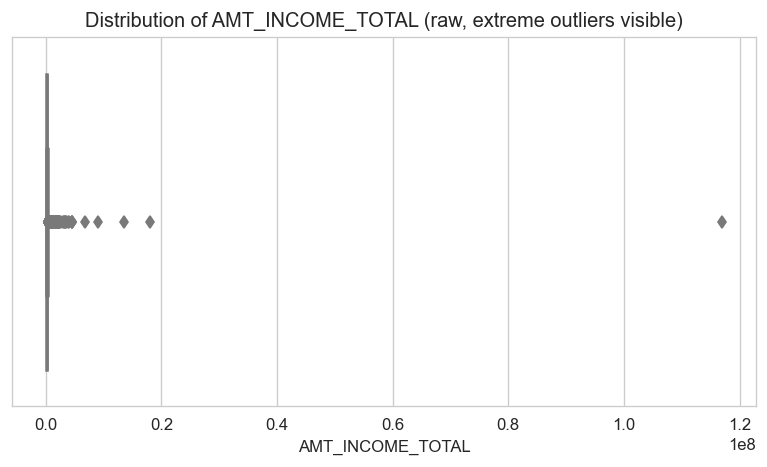

Max income: 117,000,000
Median income: 147,150


In [14]:
# Boxplot for income (known to have extreme outliers in Home Credit)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=train['AMT_INCOME_TOTAL'], ax=ax, color='lightblue')
ax.set_title('Distribution of AMT_INCOME_TOTAL (raw, extreme outliers visible)')
plt.savefig(FIG_DIR + 'outlier_income_boxplot.png')
plt.show()

print(f"Max income: {train['AMT_INCOME_TOTAL'].max():,.0f}")
print(f"Median income: {train['AMT_INCOME_TOTAL'].median():,.0f}")

---
## 6. Dtype Standardization
Ensure date-like columns are recognizable and categorical strings are stripped.
We do **not** create dummy/one-hot variables — each modeling member does this
according to their model's requirements.

In [15]:
# Strip whitespace from categorical values
for col in cat_cols:
    train[col] = train[col].astype(str).str.strip()

# DAYS_BIRTH and DAYS_EMPLOYED are stored as negative days; convert to years for readability
# (keep original columns too — modeling members may prefer raw days)
if 'DAYS_BIRTH' in train.columns:
    train['YEARS_BIRTH'] = -train['DAYS_BIRTH'] / 365.25
if 'DAYS_EMPLOYED' in train.columns:
    # Note: DAYS_EMPLOYED has sentinel value 365243 (1000 years) for unemployed clients
    train['YEARS_EMPLOYED'] = np.where(
        train['DAYS_EMPLOYED'] == 365243, np.nan,
        -train['DAYS_EMPLOYED'] / 365.25
    )

print('Added YEARS_BIRTH and YEARS_EMPLOYED (unemployed sentinel converted to NaN).')
print('Original DAYS_* columns retained.')

Added YEARS_BIRTH and YEARS_EMPLOYED (unemployed sentinel converted to NaN).
Original DAYS_* columns retained.


---
## 7. Save Cleaned Dataset

In [16]:
train.to_csv(DATA_DIR + 'application_train_cleaned.csv', index=False)
print(f'Saved cleaned data: {DATA_DIR}application_train_cleaned.csv')
print(f'Final shape: {train.shape}')

Saved cleaned data: ../data/application_train_cleaned.csv
Final shape: (307511, 124)


---
## 8. Exploratory Data Analysis (Descriptive)
All plots below are saved to `figures/` for the report.

### 8.1 Target Variable Distribution
This is the single most important EDA plot — it shows class imbalance, which
directly affects model choice and evaluation strategy (AUC-ROC, not accuracy).

Target distribution:
  0 (Repaid):     282,686 (91.93%)
  1 (Default):     24,825 (8.07%)


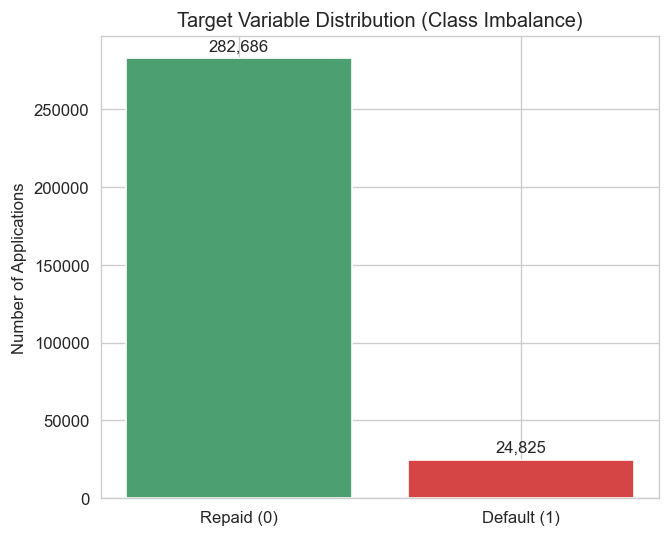

In [17]:
target_counts = train['TARGET'].value_counts()
target_ratio = train['TARGET'].value_counts(normalize=True) * 100
print('Target distribution:')
print(f'  0 (Repaid):    {target_counts[0]:>8,} ({target_ratio[0]:.2f}%)')
print(f'  1 (Default):   {target_counts[1]:>8,} ({target_ratio[1]:.2f}%)')

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Repaid (0)', 'Default (1)'], target_counts.values,
              color=['#4C9F70', '#D64545'])
ax.set_ylabel('Number of Applications')
ax.set_title('Target Variable Distribution (Class Imbalance)')
for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}', ha='center', fontsize=10)
plt.savefig(FIG_DIR + 'target_distribution.png')
plt.show()

### 8.2 Key Numeric Feature Distributions

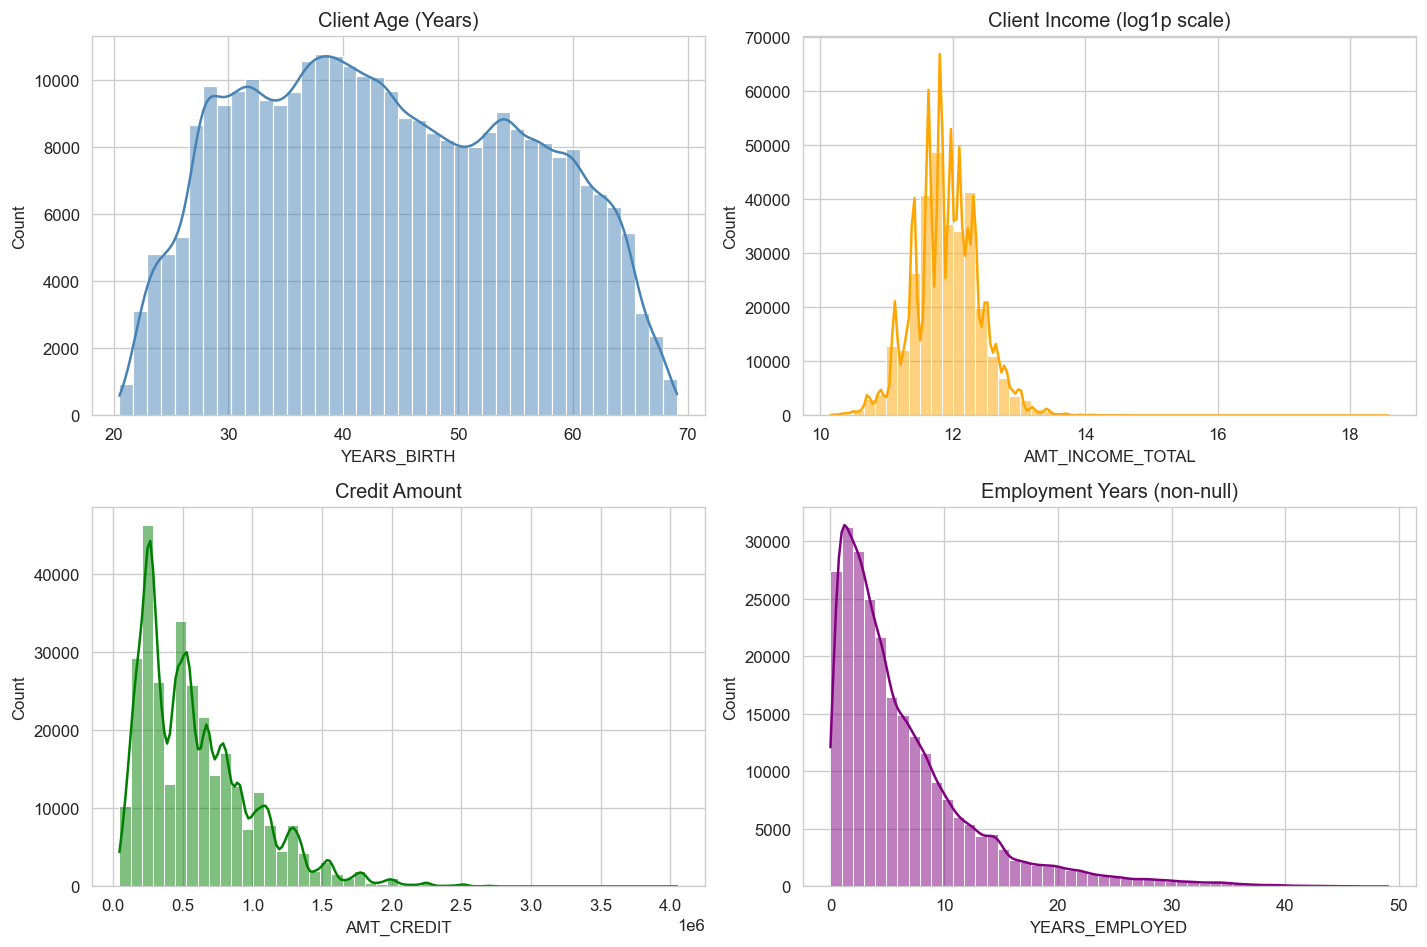

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age distribution
sns.histplot(data=train, x='YEARS_BIRTH', bins=40, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Client Age (Years)')

# Income distribution (log scale due to outliers)
sns.histplot(data=train, x=np.log1p(train['AMT_INCOME_TOTAL']), bins=50,
             kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Client Income (log1p scale)')

# Credit amount
sns.histplot(data=train, x='AMT_CREDIT', bins=50, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Credit Amount')

# Employment years
sns.histplot(data=train, x=train['YEARS_EMPLOYED'].dropna(), bins=50,
             kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Employment Years (non-null)')

plt.tight_layout()
plt.savefig(FIG_DIR + 'numeric_distributions.png')
plt.show()

### 8.3 Default Rate by Categorical Features

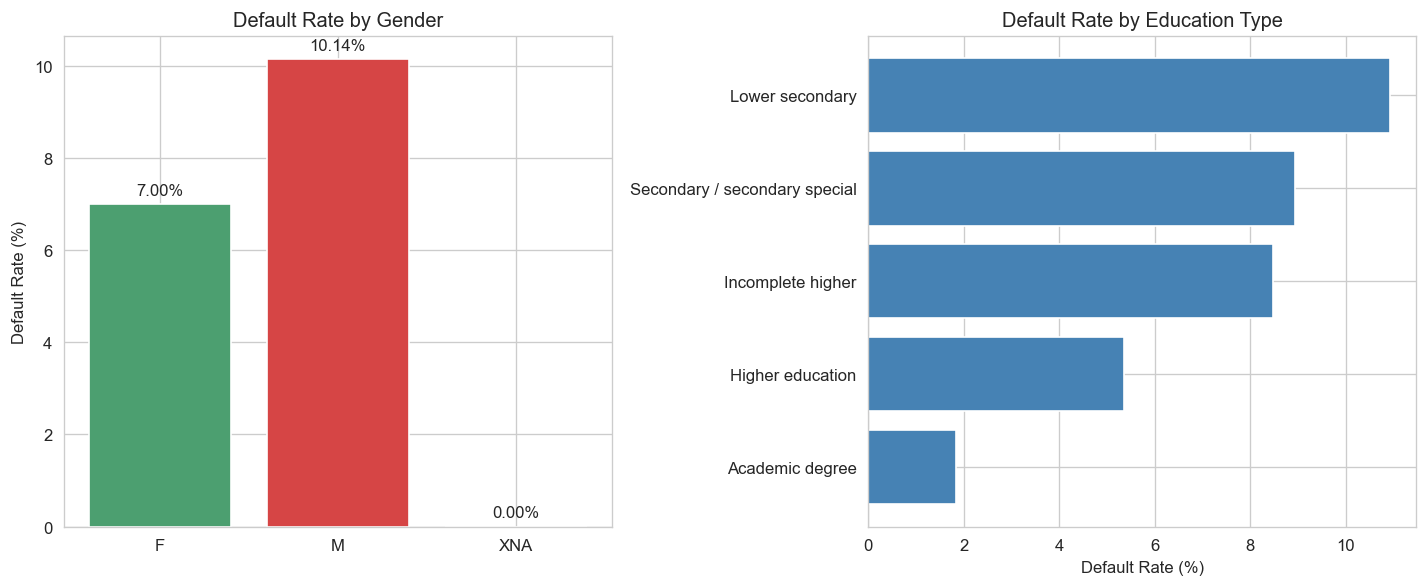

In [19]:
# Default rate by gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_default = train.groupby('CODE_GENDER')['TARGET'].mean() * 100
axes[0].bar(gender_default.index, gender_default.values, color=['#4C9F70', '#D64545'])
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Gender')
for i, v in enumerate(gender_default.values):
    axes[0].text(i, v + 0.2, f'{v:.2f}%', ha='center')

# Default rate by education type
edu_default = train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values() * 100
axes[1].barh(edu_default.index, edu_default.values, color='steelblue')
axes[1].set_xlabel('Default Rate (%)')
axes[1].set_title('Default Rate by Education Type')

plt.tight_layout()
plt.savefig(FIG_DIR + 'default_rate_by_category.png')
plt.show()

### 8.4 Correlation Heatmap (Key Features)
We select a subset of key numeric features to avoid overcrowding.

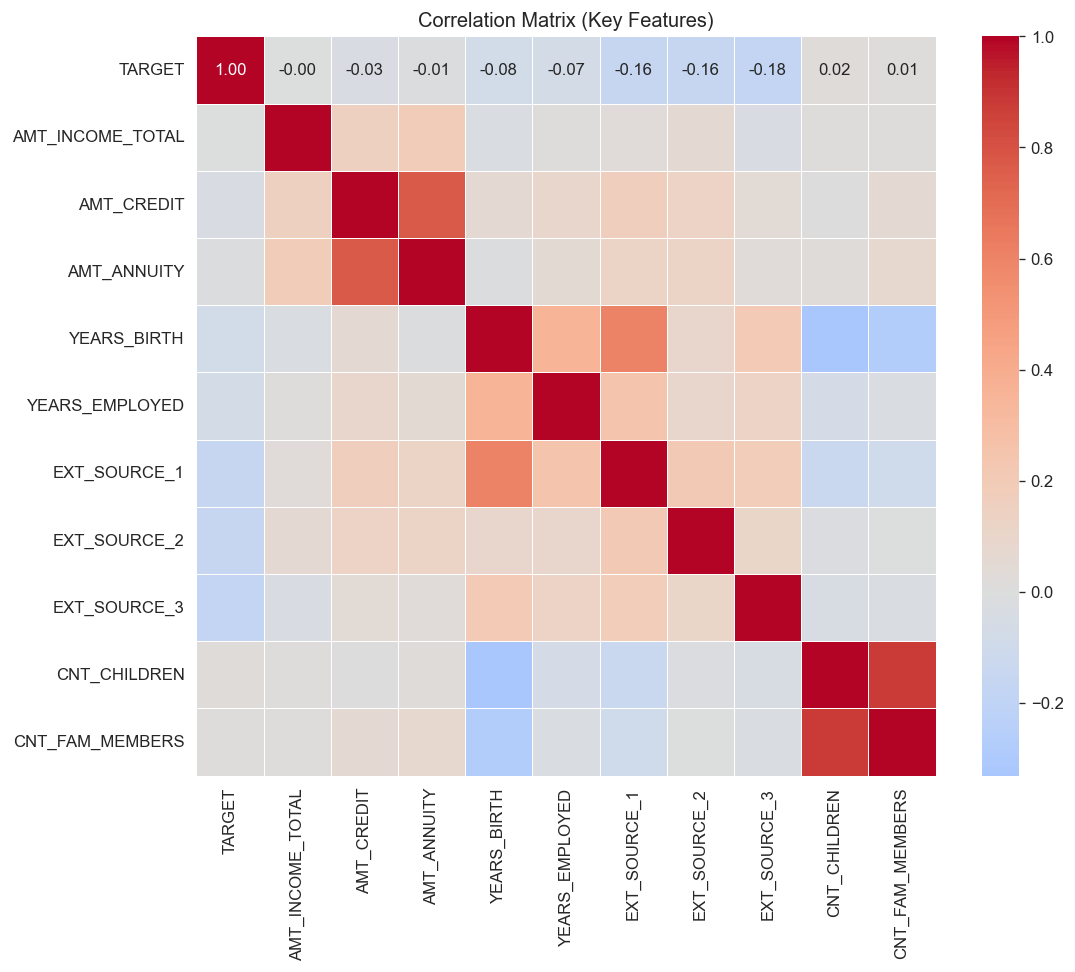

In [20]:
corr_features = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
                 'YEARS_BIRTH', 'YEARS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
                 'EXT_SOURCE_3', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
corr_features = [c for c in corr_features if c in train.columns]

corr_matrix = train[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Key Features)')
plt.savefig(FIG_DIR + 'correlation_heatmap.png')
plt.show()

### 8.5 Descriptive Statistics Table

In [21]:
desc = train[corr_features].describe().T
desc.to_csv(DATA_DIR + 'descriptive_statistics.csv')
print(desc.round(2))

                     count       mean        std       min        25%  \
TARGET            307511.0       0.08       0.27      0.00       0.00   
AMT_INCOME_TOTAL  307511.0  168797.92  237123.15  25650.00  112500.00   
AMT_CREDIT        307511.0  599026.00  402490.78  45000.00  270000.00   
AMT_ANNUITY       307499.0   27108.57   14493.74   1615.50   16524.00   
YEARS_BIRTH       307511.0      43.91      11.95     20.50      33.98   
YEARS_EMPLOYED    252137.0       6.53       6.40      0.00       2.10   
EXT_SOURCE_1      134133.0       0.50       0.21      0.01       0.33   
EXT_SOURCE_2      306851.0       0.51       0.19      0.00       0.39   
EXT_SOURCE_3      246546.0       0.51       0.19      0.00       0.37   
CNT_CHILDREN      307511.0       0.42       0.72      0.00       0.00   
CNT_FAM_MEMBERS   307509.0       2.15       0.91      1.00       2.00   

                        50%        75%           max  
TARGET                 0.00       0.00  1.000000e+00  
AMT_INCOME_TO

---
## 9. Summary & Handoff Notes for Modeling Members

### What was done:
- Main application table loaded and inspected
- Missing value statistics computed and saved
- Categorical NaN → `'Unknown'`; numeric NaN left as-is
- Duplicate rows checked
- Outliers documented (not removed)
- Added `YEARS_BIRTH`, `YEARS_EMPLOYED` derived columns
- Class imbalance quantified (~92% vs ~8%)

### What modeling members need to do themselves:
- **One-hot / label encoding** for categorical variables
- **Feature scaling** (required for Logistic Regression; optional for tree models)
- **Missing value imputation** strategy (median, mean, or model-native)
- **Feature selection** based on their model's importance scores
- **Class imbalance handling** (class weights, SMOTE, etc.)
- Optional: merge supplementary tables (`bureau.csv`, `previous_application.csv`, etc.)

### Key data quirks to remember:
- `DAYS_EMPLOYED = 365243` is a sentinel for unemployed (converted to NaN in `YEARS_EMPLOYED`)
- `AMT_INCOME_TOTAL` has extreme outliers (max >> median)
- Several features have > 40% missing (documented in `missing_statistics.csv`)

In [1]:
import os
import pandas as pd

raw_dir = '../data/raw/'
files = ['application_train.csv', 'bureau.csv', 'bureau_balance.csv',
         'previous_application.csv', 'POS_CASH_balance.csv',
         'credit_card_balance.csv', 'installments_payments.csv']

for f in files:
    path = raw_dir + f
    if os.path.exists(path):
        print(f'{f:35s} OK')
    else:
        print(f'{f:35s} NOT FOUND!')


application_train.csv               OK
bureau.csv                          OK
bureau_balance.csv                  OK
previous_application.csv            OK
POS_CASH_balance.csv                OK
credit_card_balance.csv             OK
installments_payments.csv           OK


In [2]:
# 加载bureau.csv
bureau = pd.read_csv('../data/raw/bureau.csv')
print(f'bureau shape: {bureau.shape}')
print(bureau.head())


bureau shape: (1716428, 17)
   SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0      215354       5714462        Closed      currency 1         -497   
1      215354       5714463        Active      currency 1         -208   
2      215354       5714464        Active      currency 1         -203   
3      215354       5714465        Active      currency 1         -203   
4      215354       5714466        Active      currency 1         -629   

   CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
0                   0               -153.0             -153.0   
1                   0               1075.0                NaN   
2                   0                528.0                NaN   
3                   0                  NaN                NaN   
4                   0               1197.0                NaN   

   AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  AMT_CREDIT_SUM  \
0                     NaN                   0         91323.0   
1     

In [5]:
import pandas as pd
import numpy as np
train = pd.read_csv('../data/raw/application_train.csv')
print(f'主表: {train.shape}')


主表: (307511, 122)


In [6]:
bureau = pd.read_csv('../data/raw/bureau.csv')
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_COUNT = ('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_AVG_CREDIT = ('AMT_CREDIT_SUM', 'mean'),
    BUREAU_MAX_CREDIT = ('AMT_CREDIT_SUM', 'max'),
    BUREAU_AVG_DEBT = ('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_MAX_OVERDUE = ('AMT_CREDIT_MAX_OVERDUE', 'max'),
).reset_index()
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')
print(f'合并bureau后: {train.shape}')


合并bureau后: (307511, 129)


In [7]:
prev = pd.read_csv('../data/raw/previous_application.csv')
prev_agg = prev.groupby('SK_ID_CURR').agg(
    PREV_COUNT = ('SK_ID_PREV', 'count'),
    PREV_APPROVED = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_AVG_AMT = ('AMT_APPLICATION', 'mean'),
    PREV_MAX_AMT = ('AMT_APPLICATION', 'max'),
    PREV_AVG_ANNUITY = ('AMT_ANNUITY', 'mean'),
    PREV_AVG_DAYS_DECISION = ('DAYS_DECISION', 'mean'),
).reset_index()
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')
print(f'合并previous后: {train.shape}')


合并previous后: (307511, 136)


In [8]:
install = pd.read_csv('../data/raw/installments_payments.csv')
install_agg = install.groupby('SK_ID_CURR').agg(
    INSTALL_COUNT = ('SK_ID_PREV', 'count'),
    INSTALL_AVG_PAYMENT = ('AMT_PAYMENT', 'mean'),
    INSTALL_MAX_PAYMENT = ('AMT_PAYMENT', 'max'),
    INSTALL_AVG_DAYS_LATE = ('DAYS_ENTRY_PAYMENT', 'mean'),
).reset_index()
train = train.merge(install_agg, on='SK_ID_CURR', how='left')
print(f'合并installments后: {train.shape}')


合并installments后: (307511, 140)


In [9]:
pos = pd.read_csv('../data/raw/POS_CASH_balance.csv')
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_COUNT = ('SK_ID_PREV', 'count'),
    POS_AVG_CNT = ('CNT_INC_PAST_DUE', 'mean'),
    POS_MAX_CNT = ('CNT_INC_PAST_DUE', 'max'),
).reset_index()
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')
print(f'合并POS后: {train.shape}')


KeyError: "Column(s) ['CNT_INC_PAST_DUE'] do not exist"

In [10]:
pos = pd.read_csv('../data/raw/POS_CASH_balance.csv')
print(pos.columns.tolist())


['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']


In [11]:
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_COUNT = ('SK_ID_PREV', 'count'),
    POS_AVG_DPD = ('SK_DPD', 'mean'),
    POS_MAX_DPD = ('SK_DPD', 'max'),
    POS_AVG_DPD_DEF = ('SK_DPD_DEF', 'mean'),
).reset_index()
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')
print(f'合并POS后: {train.shape}')


合并POS后: (307511, 144)


In [12]:
cc = pd.read_csv('../data/raw/credit_card_balance.csv')
print(cc.columns.tolist())


['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']


In [13]:
cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_COUNT = ('SK_ID_PREV', 'count'),
    CC_AVG_BALANCE = ('AMT_BALANCE', 'mean'),
    CC_MAX_BALANCE = ('AMT_BALANCE', 'max'),
    CC_AVG_LIMIT = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    CC_AVG_DPD = ('SK_DPD', 'mean'),
).reset_index()
train = train.merge(cc_agg, on='SK_ID_CURR', how='left')
print(f'合并creditcard后: {train.shape}')


合并creditcard后: (307511, 149)


In [ ]:
# 类别缺失值填Unknown
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    train[col] = train[col].fillna('Unknown')

# Common Features
train['INCOME_CREDIT_RATIO'] = train['AMT_INCOME_TOTAL'] / train['AMT_CREDIT']
train['ANNUITY_INCOME_RATIO'] = train['AMT_ANNUITY'] / train['AMT_INCOME_TOTAL']
train['YEARS_BIRTH'] = -train['DAYS_BIRTH'] / 365.25
train['YEARS_EMPLOYED'] = np.where(
    train['DAYS_EMPLOYED'] == 365243, np.nan,
    -train['DAYS_EMPLOYED'] / 365.25
)

# 保存
train.to_csv('../data/application_train_full.csv', index=False)
print(f'完成! 最终: {train.shape}')
print(f'已保存到: ../data/application_train_full.csv')
